# Group Project - Group 4
## **Data Analysis on Spotify: Music Clustering for Spotify Playlist Generation**


Group Members:
*   Ting Chi, WANG
*   Yi Chun, HSIAO
*   Sheng Che, LIN
*   Paula Ortiz

**Business Problems (Marketing Analytics)**

How can song audio features (such as danceability, energy, valence, tempo) be used to automatically group songs to match specific moods or activities (e.g., 'workout', 'relax', 'party' playlists)

**Objectives**

Improve the recommendation quality of algorithmic playlists and user experience



---



## **1. Data Import and Exploration**

### 1.a Import the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

### 1.b Import the Dataset from Kaggle


> Spotify Tracks Dataset from Kaggle:　https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset



In [ ]:
# Upload CSV file
uploaded = files.upload()

Saving spotify_dataset.csv to spotify_dataset (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('spotify_dataset.csv')
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.042,0.640,0.928,0.086,0.034,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.040,0.994,0.976,0.105,0.035,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.042,0.867,0.000,0.084,0.743,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.030,0.381,0.000,0.270,0.413,135.960,4,world-music


### 1.3 Data Exploration

In [ ]:
print("Shape of the dataset:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nStatistical summary:")
display(df.describe(include="all"))

Shape of the dataset: (114000, 21)

Column names:
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

Data types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

F

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic



Statistical summary:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,114000.000,114000,113999,113999,113999,114000.000,114000.000,114000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000
unique,NaN,89741,31437,46589,73608,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,NaN,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,NaN,9,279,195,151,NaN,NaN,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,56999.500,NaN,NaN,NaN,NaN,33.239,228029.153,NaN,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904,NaN
std,32909.110,NaN,NaN,NaN,NaN,22.305,107297.713,NaN,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433,NaN
min,0.000,NaN,NaN,NaN,NaN,0.000,0.000,NaN,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN
25%,28499.750,NaN,NaN,NaN,NaN,17.000,174066.000,NaN,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000,NaN
50%,56999.500,NaN,NaN,NaN,NaN,35.000,212906.000,NaN,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000,NaN
75%,85499.250,NaN,NaN,NaN,NaN,50.000,261506.000,NaN,0.695,0.854,8.000,-5.003,1.000,0.085,0.598,0.049,0.273,0.683,140.071,4.000,NaN


## **2. Data Cleaning**

### 2.1 Check Missing Values and Duplicates

In [ ]:
print("Missing values per column:")
display(df.isnull().sum().to_frame(name="Missing_Values"))
print("Number of duplicated rows:", df.duplicated().sum())

Missing values per column:


,Missing_Values
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


Number of duplicated rows: 0


### 2.2 Clean the data

In [ ]:
# Fill missing values in the categorical column 'degree' with the mode
df["artists"] = df["artists"].fillna(df["artists"].mode()[0])
df["album_name"] = df["album_name"].fillna(df["album_name"].mode()[0])
df["track_name"] = df["track_name"].fillna(df["track_name"].mode()[0])

# Remove duplicated rows if any
df = df.drop_duplicates()
print("Missing values after cleaning:")
display(df.isnull().sum().to_frame(name="Missing_Values_After_Cleaning"))
print("Number of duplicated rows after cleaning:",
df.duplicated().sum())

# Remove unnamed columns
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Shape of the dataset after cleaning:", df.shape)

Missing values after cleaning:


,Missing_Values_After_Cleaning
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


Number of duplicated rows after cleaning: 0
Shape of the dataset after cleaning: (114000, 20)


## **3. Data Frame Manipulation**

### 3.1 Feature Correlation Analysis
The purpose of this step is to detect multicollinearity among our audio features. By visualizing the correlation matrix, we can identify variables that are highly linearly dependent. Since our upcoming K-Means clustering algorithm calculates spatial distances between data points, retaining overlapping features can distort these distances and skew the final clusters. Analyzing these relationships allows us to filter out redundant signals and optimize our feature set for accurate segmentation.

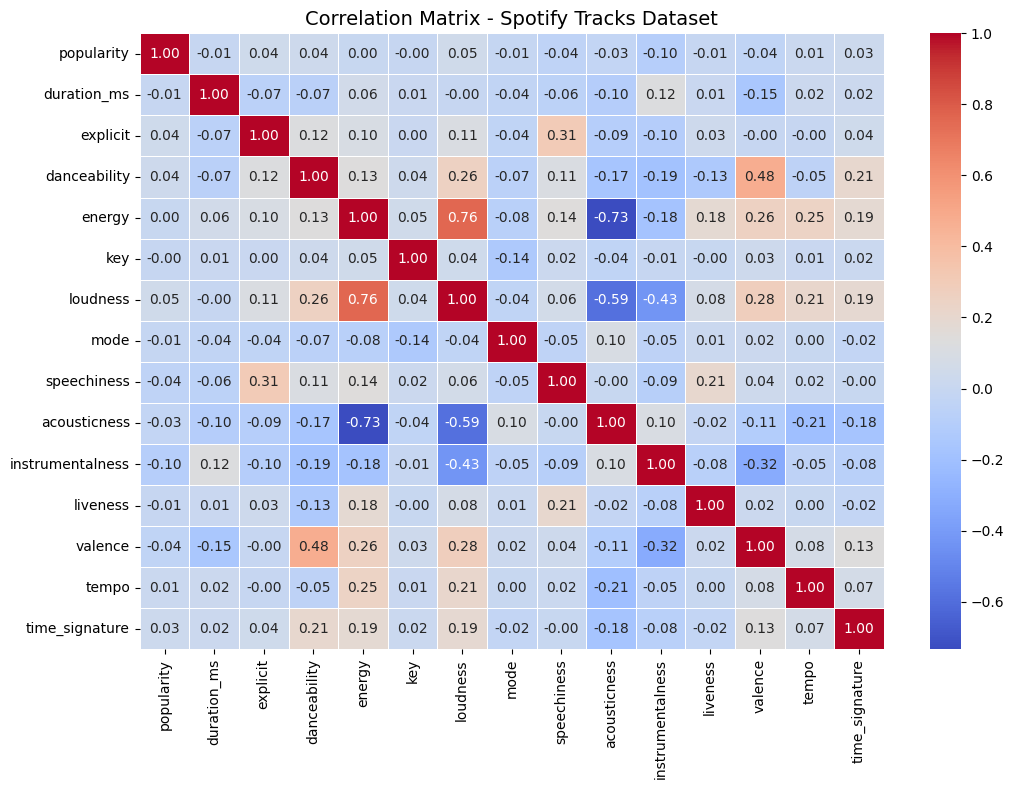

In [ ]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Spotify Tracks Dataset", fontsize=14)
plt.show()

**Feature Selection based on Correlation Analysis**

Based on our data analysis using the correlation matrix, we identified a **strong positive correlation ($r = 0.76$) between energy and loudness**.Since the K-Means algorithm relies on distance metrics (like Euclidean distance) to assign clusters, including highly correlated variables can distort the results. Specifically, keeping both features would essentially "double-weight" the intensity aspect of the tracks, causing the model to overemphasize how loud or energetic a song is at the expense of other important musical traits.

To prevent this multicollinearity issue and ensure a balanced feature space, we decided to drop loudness and retain energy, as energy serves as a more comprehensive perceptual measure of a track's overall intensity. We retained the remaining **8 numerical features (danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence, tempo)**. These features capture distinct and relatively independent dimensions of the audio data, providing a robust and well-rounded foundation for our clustering model.

### 3.2 Feature Scaling

In [ ]:
# 1. Select relevant numerical features for clustering
features = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

# 2. Extract the feature matrix
X = df[features]

# 3. Scale the features (Crucial parameter adjustment)
# This ensures all features contribute equally to the distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with scaled values for inspection
df_scaled = pd.DataFrame(X_scaled, columns=features)
print("Scaled features summary (Mean should be ~0, Std should be ~1):")
display(df_scaled.describe())

print(f"\nPrepared {len(features)} features for analysis: {features}")

Scaled features summary (Mean should be ~0, Std should be ~1):


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.266,-2.550,-0.801,-0.947,-0.504,-1.122,-1.829,-4.075
25%,-0.638,-0.673,-0.461,-0.896,-0.504,-0.607,-0.826,-0.765
50%,0.076,0.173,-0.338,-0.439,-0.504,-0.428,-0.039,-0.004
75%,0.739,0.845,-0.001,0.851,-0.346,0.312,0.806,0.598
max,2.410,1.426,8.326,2.048,2.726,4.131,2.009,4.044



Prepared 8 features for analysis: ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


## **4. Clustering: K-Means**

### 4.1 Determine the Optimal Number of Clusters (Elbow Method)

Choosing the correct number of clusters is a critical step in K-Means. Here, we apply the Elbow Method by tracking the **Within-Cluster Sum of Squares (WCSS)** for multiple $K$ configurations. Our goal is to locate the "elbow" on the resulting curve: the sweet spot where the model successfully captures the data's underlying structure without unnecessarily over-segmenting it.

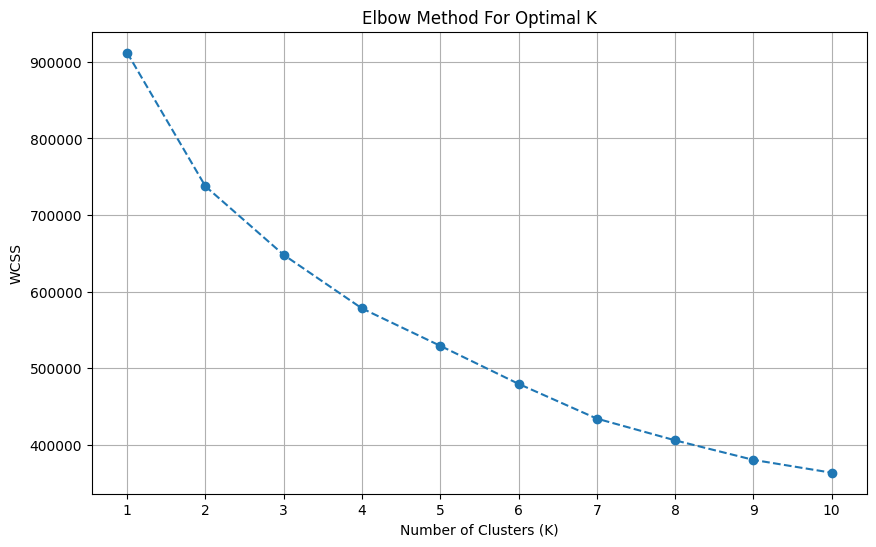

In [ ]:
from sklearn.cluster import KMeans

wcss = []
# Try from 1 to 10 cluster
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Identifying the Elbow Point:** The WCSS shows a steep drop between $K=1$ and $K=2$, followed by a visible bend at $K=3$. After $K=3$, the curve flattens out, meaning additional clusters provide diminishing returns in reducing variance.

**Final Verdict:** While the "elbow" isn't perfectly sharp, $K=3$ represents the best balance between model complexity and data fit. We will proceed with 3 clusters for our playlist curation, with $K=2$ as a secondary option for maximum simplicity.

### 4.2 Apply K-Means Clustering

Based on the insights gathered from our Elbow Method analysis, we have identified the optimal number of clusters to be $K=3$. In this step, we initialize and fit the K-Means algorithm to our standardized feature set, partitioning the songs into three distinct musical profiles.

In [ ]:
# Choose optimal K using Elbow Method
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Run clustering on scaled features
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataset
df['cluster'] = clusters

print(f"Number of data points assigned to {optimal_k} clusters.")
display(df[['track_name', 'artists', 'cluster']].head())

Number of data points assigned to 3 clusters.


,track_name,artists,cluster
0,Comedy,Gen Hoshino,0
1,Ghost - Acoustic,Ben Woodward,1
2,To Begin Again,Ingrid Michaelson;ZAYN,1
3,Can't Help Falling In Love,Kina Grannis,1
4,Hold On,Chord Overstreet,1


### 4.3 Visualizing Clusters in Reduced Dimensional Space

With 8 distinct audio features, direct high-dimensional visualization is not feasible. To overcome this, we apply Principal Component Analysis (PCA) to project these 8 dimensions into a 2-component subspace. This mathematical compression allows us to plot our 3 clusters on a 2D map, providing a visual representation of the data's structure while retaining as much of the original variance and relationships as possible.

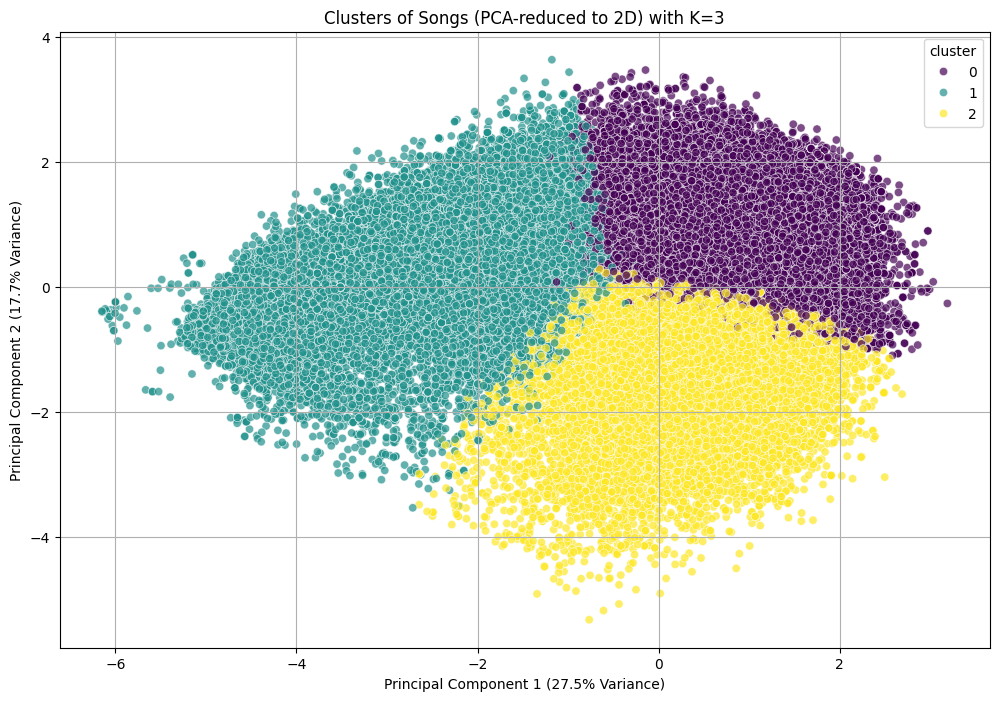

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reduce dimensions of the 8 features to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA coordinates to DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])
df_pca['cluster'] = df['cluster'] # Include cluster labels for coloring

# Extract the explained variance to see how much info we kept from the 8 features
explained_variance = pca.explained_variance_ratio_ * 100

# Plot the final 2D cluster visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='cluster',
    palette='viridis',
    data=df_pca,
    legend='full',
    alpha=0.7
)
plt.title(f'Clusters of Songs (PCA-reduced to 2D) with K={optimal_k}')

# Dynamically inject the variance percentage into the labels
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}% Variance)')
plt.grid(True)
plt.show()

### 4.4 Interpret PCA Components (Feature Loadings)
While our 2D scatter plot clearly shows how the clusters separate, the principal components (PC1 and PC2) themselves are abstract mathematical combinations. To understand what these axes actually represent in terms of real audio characteristics, we extract the "feature loadings" (weights) from our PCA model. This heatmap visualizes how strongly each of our original 8 features contributes to PC1 and PC2, allowing us to decode and translate our 2D map back into meaningful musical dimensions.

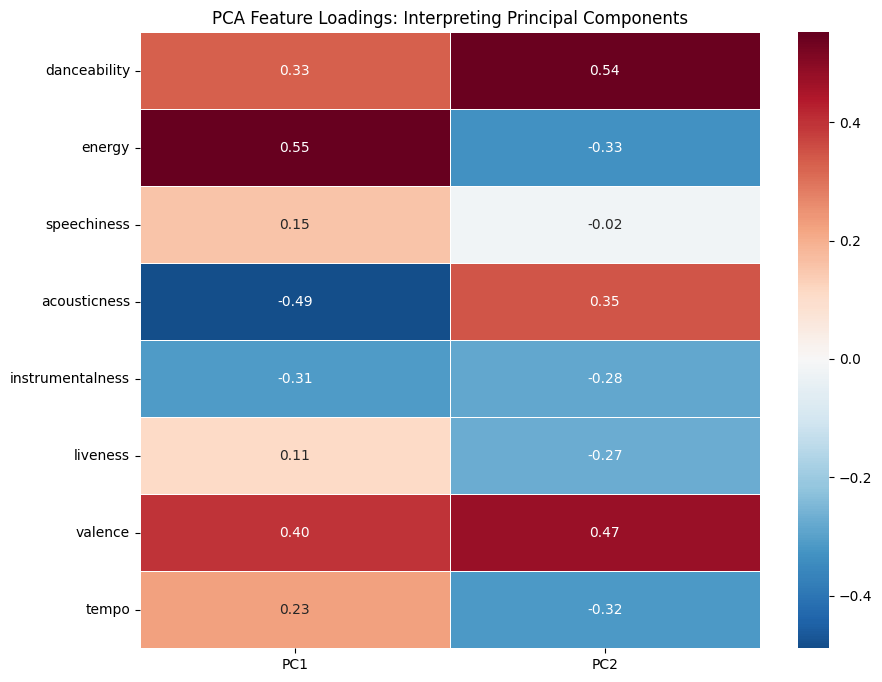

In [ ]:
# Extract the PCA components (feature weights) and transpose (.T) them.
# This matrix reveals the linear combination of original features that make up PC1 and PC2.
# A value close to 1 or -1 indicates a strong positive/negative influence on that component.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

# Plot a heatmap to visualize the feature loadings for interpretation
plt.figure(figsize=(10, 8))
sns.heatmap(
    loadings,
    annot=True,          # Show the correlation values in the cells
    cmap='RdBu_r',       # Red for positive correlation, Blue for negative
    center=0,            # Center the colormap at 0 for clear distinction
    fmt='.2f',           # Format numbers to 2 decimal places
    linewidths=0.5
)
plt.title('PCA Feature Loadings: Interpreting Principal Components')
plt.show()

## **5. Data Visualization**
### Cluster Profiling and Feature Analysis

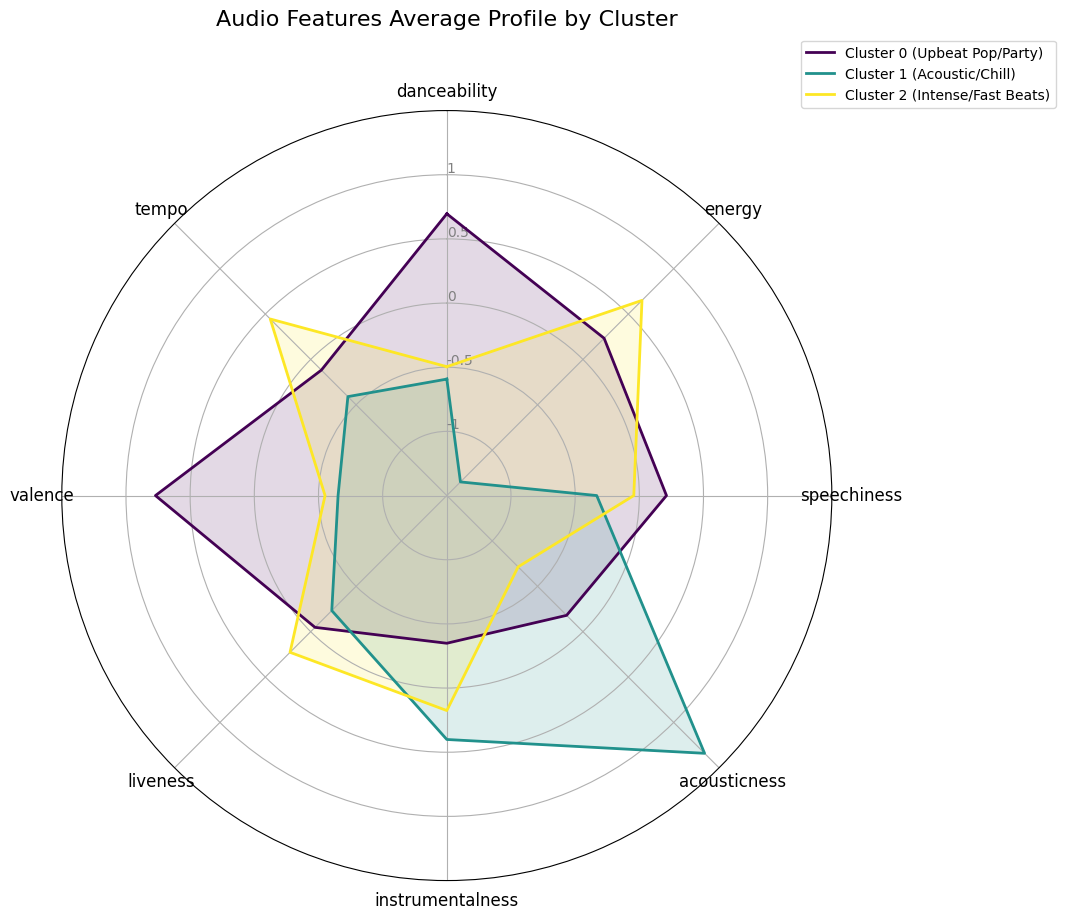

In [ ]:
# 1. Ensure df_scaled contains cluster features labels
if 'cluster' not in df_scaled.columns:
    df_scaled['cluster'] = df['cluster'].values

# 2. Caculate the means of each cluster
cluster_means = df_scaled.groupby('cluster')[features].mean()

# 3. Parameters for the Rader Graaph
categories = features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 4. Plot the Radar graph
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, size=12)

ax.set_rlabel_position(0)
plt.yticks([-1, -0.5, 0, 0.5, 1], ["-1", "-0.5", "0", "0.5", "1"], color="grey", size=10)
plt.ylim(-1.5, 1.5)

# 5. Define the colors and labels
colors = ['#440154', '#21918c', '#fde725']
labels = ['Cluster 0 (Upbeat Pop/Party)',
          'Cluster 1 (Acoustic/Chill)',
          'Cluster 2 (Intense/Fast Beats)']

# 6. Plot the three clusters
for i, color in enumerate(colors):
    values = cluster_means.loc[i].values.flatten().tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid', label=labels[i])
    ax.fill(angles, values, color=color, alpha=0.15)

plt.title('Audio Features Average Profile by Cluster', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

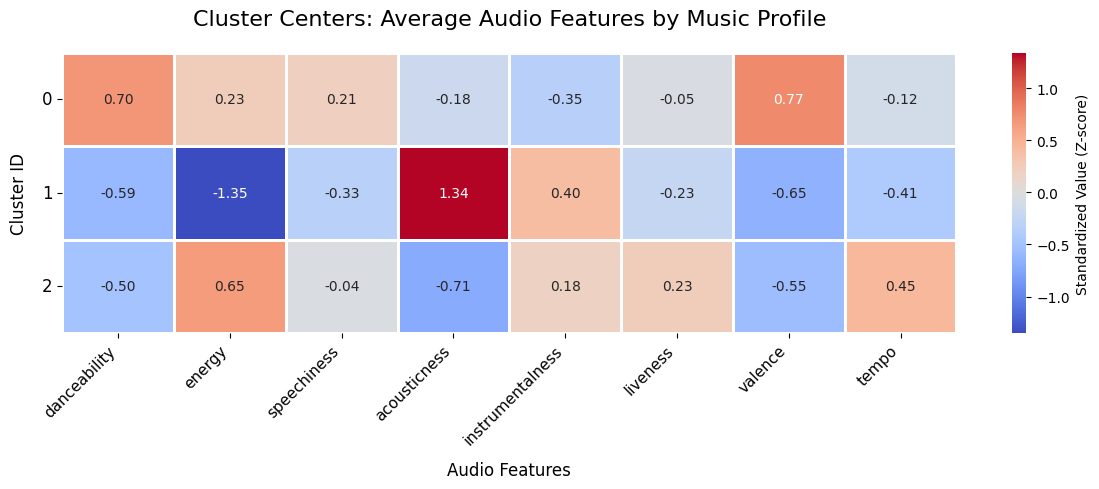

In [ ]:
# 1. Calculate the mean values of each feature for each cluster
# This creates a matrix where rows are clusters and columns are feature averages
cluster_means = df_scaled.groupby('cluster')[features].mean()

# 2. Initialize the matplotlib figure
plt.figure(figsize=(12, 5))

# 3. Create the heatmap
# annot=True: displays the exact numbers inside the boxes
# cmap='coolwarm': perfect for standardized data (Red = above average, Blue = below average)
# fmt='.2f': formats the numbers to 2 decimal places
sns.heatmap(
    cluster_means,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=1,
    cbar_kws={'label': 'Standardized Value (Z-score)'}
)

# 4. Customize titles and labels for a clean, professional look
plt.title('Cluster Centers: Average Audio Features by Music Profile', fontsize=16, pad=20)
plt.xlabel('Audio Features', fontsize=12, labelpad=10)
plt.ylabel('Cluster ID', fontsize=12, labelpad=10)

# Rotate x-axis labels so the feature names are easily readable
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=12, rotation=0)

# Automatically adjust the layout so nothing gets cut off
plt.tight_layout()

# Display the clean and focused heatmap
plt.show()

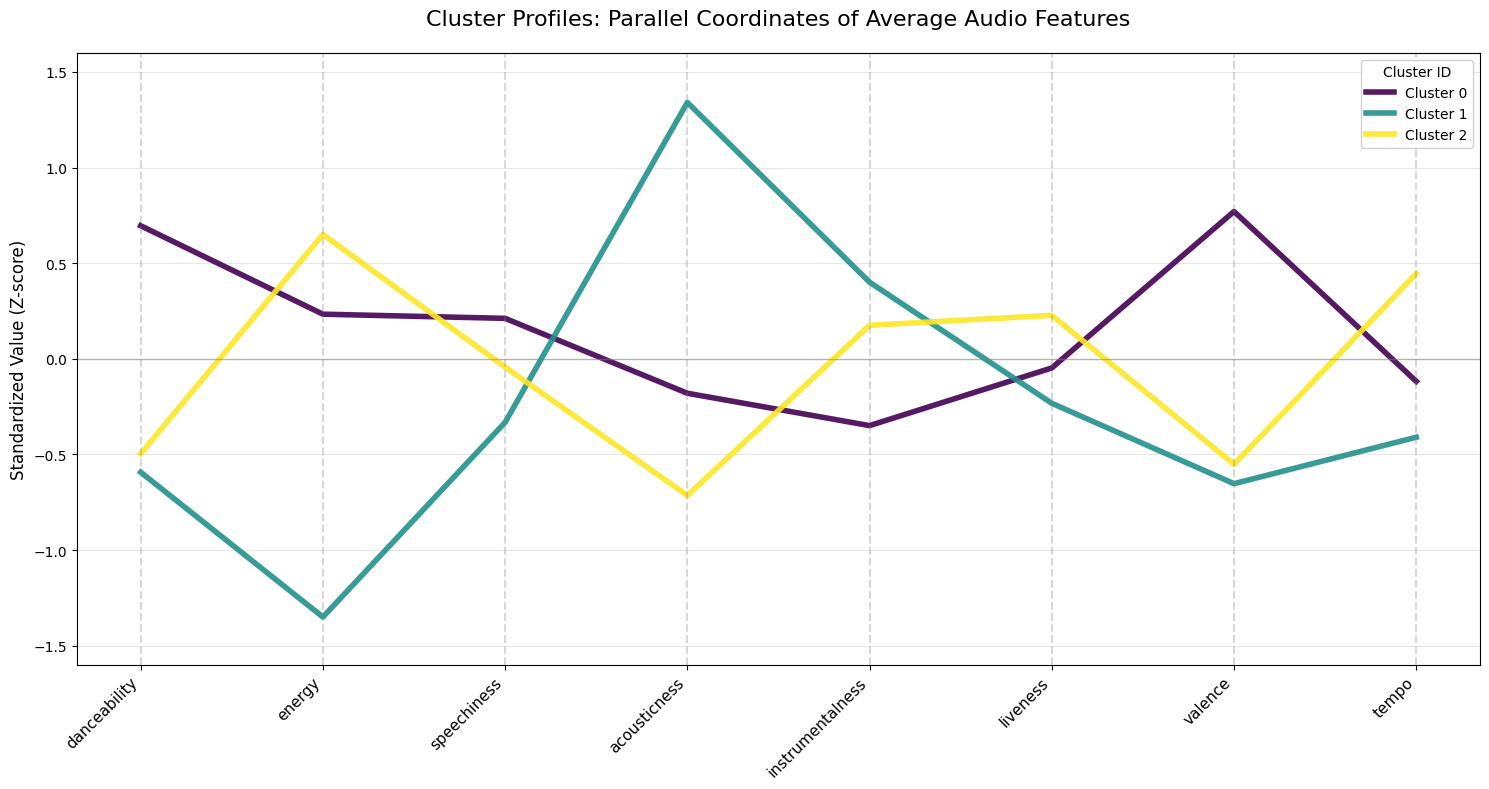

In [ ]:
# 1. Prepare data (use standardized features + cluster label)
plot_data = df_scaled.copy()
if 'cluster' not in plot_data.columns:
    plot_data['cluster'] = df['cluster'].values

# 2. Calculate Cluster Means (Centroids) for the clean visualization
cluster_means = plot_data.groupby('cluster')[features].mean()

# 3. Setup the Parallel Coordinates Plot manually using matplotlib for precise control
# Setting up axes
fig, ax = plt.subplots(figsize=(15, 8))

# X-axis indices based on feature count
x = np.arange(len(features))

# Define colors (matching viridis palette used in previous plots)
colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_means)))

# 4. Plot thick lines for each cluster mean (centroid path)
# We plot means only to avoid a cluttered "spaghetti plot"
for i, cluster in enumerate(cluster_means.index):
    # Fetch standardized values for the cluster across all 8 features
    y = cluster_means.loc[cluster].values

    # Plot the thick line with some transparency (alpha)
    ax.plot(
        x, y,
        color=colors[i],
        linewidth=4,            # Thick line for easy viewing
        label=f'Cluster {cluster}',
        alpha=0.9
    )

# 5. Draw vertical axes lines for each feature (Parallel Coordinates)
# Standard Z-score reference line at 0 (average)
ax.axhline(0, color='grey', linestyle='-', alpha=0.5, linewidth=1)

# Vertical lines for feature boundaries
for x_val in x:
    ax.axvline(x=x_val, color='grey', linestyle='--', alpha=0.3)

# 6. Customize titles, labels, and tick formatting for clarity
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Standardized Value (Z-score)', fontsize=12)
ax.set_title('Cluster Profiles: Parallel Coordinates of Average Audio Features', fontsize=16, pad=20)
ax.set_ylim(-1.6, 1.6) # Set y-axis limits to accommodate all mean data points

# Place legend in a clear location
ax.legend(title='Cluster ID', loc='upper right', framealpha=0.9)

# Add horizontal gridlines for easier value comparison
ax.grid(axis='y', linestyle='-', alpha=0.3)

# Adjust layout automatically
plt.tight_layout()

# Display the Parallel Coordinates plot
plt.show()

## **6. Data Analysis**

### **PCA & Clustering Analysis: Uncovering Musical Profiles**

This analysis evaluates the results of a K-Means clustering algorithm ($K=3$) applied to audio features. To provide a reliable and interpretable visualization, the data was projected into a 2D space using Principal Component Analysis (PCA), with the two principal components retaining 45.2% of the total variance from the original 8-dimensional feature space.

#### **1. Interpreting the Principal Components (Dimensionality Reduction)**
By analyzing the PCA feature loadings, we can define the musical meaning behind the axes of our scatter plot:

* **Principal Component 1 (X-axis: 27.5% Variance) - "Acoustic/Instrumental vs. High-Energy/Electronic"**
  * **Positive Drivers:** `energy` (0.55), `valence` (0.40), and `danceability` (0.33).
  * **Negative Drivers:** `acousticness` (-0.49) and `instrumentalness` (-0.31).
  * **Insight:** Moving from left to right along the X-axis, tracks transition from quiet, acoustic, and instrumental compositions to highly energetic, electronic, and upbeat modern tracks.

* **Principal Component 2 (Y-axis: 17.7% Variance) - "Intense/Fast vs. Chill/Happy Groove"**
  * **Positive Drivers:** `danceability` (0.54), `valence` (0.47), and `acousticness` (0.35).
  * **Negative Drivers:** `energy` (-0.33) and `tempo` (-0.32).
  * **Insight:** Moving from bottom to top along the Y-axis, tracks become more danceable and positive, but surprisingly drop in raw energy and tempo. The upper quadrant represents relaxed, highly rhythmic, and happy music, while the lower quadrant points toward fast, aggressive, or heavy tracks.

#### **2. Cluster Profiling & Feature Signatures**
The provided visualizations—the scatter plot, radar chart, cluster centers heatmap, and parallel coordinates plot—collectively illustrate the distinct audio feature signatures of the three K-Means clusters. By integrating their PCA positions with their standardized mean values (Z-scores), we can accurately define their musical profiles:

* **Cluster 0: The Upbeat Party Hits (Purple)**
  * **Profile & Position:** Occupying the top-right quadrant of the PCA plot, this cluster is characterized by high positive values in `valence` (0.77) and `danceability` (0.70), alongside moderately high `energy` (0.23).
  * **Insight:** As seen clearly in the radar chart's outward stretch towards these metrics and the deep red hues in the heatmap, this group represents happy, energetic, and highly danceable tracks—typical of upbeat pop, disco, or party music. Furthermore, its negative `instrumentalness` score suggests a strong presence of vocals.

* **Cluster 1: The Acoustic & Chill Zone (Teal)**
  * **Profile & Position:** Strictly occupying the negative side of PC1, this profile stands in stark contrast to the others. The most defining feature is its extreme positive spike in `acousticness` (1.34), accompanied by the lowest `energy` level (-1.35) in the dataset.
  * **Insight:** The parallel coordinates plot highlights this dramatic shift perfectly, showing the teal line peaking sharply at acousticness before plunging down for energy, valence, and danceability. This cluster firmly represents calm, unplugged, acoustic, or classical music that is low-tempo and not intended for dancing.

* **Cluster 2: The Intense & Heavy Beats (Yellow)**
  * **Profile & Position:** Occupying the bottom-right quadrant of the PCA plot, this cluster is driven by intensity. It scores the highest in raw `energy` (0.65) and `tempo` (0.45), while completely lacking acoustic elements (scoring -0.71 in `acousticness`).
  * **Insight:** Interestingly, unlike Cluster 0, this high energy does not translate to high danceability or valence (both are negative). This indicates a collection of fast, loud, and electronically amplified tracks that are intense rather than cheerful, characteristic of heavy rock, hard EDM, or fast-paced workout music.

#### **Conclusion**
The combination of PCA dimensionality reduction and K-Means feature analysis confirms that our algorithm successfully segmented the dataset into three highly logical and distinct musical archetypes: Calm/Acoustic, Happy/Danceable Pop, and Intense/Fast-paced. The alignment across all visualization methods strongly validates the robustness of our cluster definitions, forming a solid foundation for applications like automated playlist generation or music recommendation systems.